# Geospatial Streaming Analytics with Stratified Sampling

This notebook demonstrates:
* **Spark Structured Streaming** with tumbling windows (no watermarks)
* **Geohash-based stratified sampling** for spatial data reduction
* **Spatial joins** using geopandas and shapely for point-in-polygon operations
* **Accuracy comparison** between full streaming data and sampled data using RMSE and MAPE

## Configuration
* **Sampling Fraction**: 30% per geohash stratum
* **Geohash Precision**: 7 (approximately 153m × 153m cells)
* **Window Duration**: 10 seconds (tumbling windows)
* **Dataset**: Chicago air quality sensor data (129,531 records)
* **Neighborhoods**: 98 Chicago neighborhoods from GeoJSON

## Cell 1: Streaming Pipeline with Geohash Stratified Sampling

### What This Cell Does:

**1. Setup & Configuration**
* Defines schema for air quality sensor data (PM2.5, temperature, humidity, etc.)
* Configures sampling parameters and window duration
* Prepares streaming directory and checkpoint locations

**2. Load Geospatial Data**
* Loads Chicago neighborhood boundaries from GeoJSON using geopandas
* Broadcasts neighborhood geometries to all Spark workers for efficient spatial joins

**3. Define UDFs**
* `geohash_udf`: Generates geohash codes (precision 7) for each sensor location
* `find_neighborhood_udf`: Performs point-in-polygon check using shapely to find which neighborhood contains each sensor reading

**4. Streaming Path (Full Data)**
* Reads CSV as a **Spark Structured Stream**
* Adds geohash and neighborhood columns using UDFs
* Aggregates by **10-second tumbling windows** and neighborhood (NO watermark)
* Writes results to in-memory table `full_data_results`
* Polls until streaming query processes data (up to 60 seconds)

**5. Batch Path (Sampled Data)**
* Reads same CSV as **batch** (required for sampling)
* Generates geohash for each record
* Performs **stratified sampling by geohash** (30% from each geohash cell)
* Applies same spatial join and window aggregation as streaming path

**6. Comparison**
* Joins full streaming results with sampled batch results
* Calculates error metrics: squared error and absolute percentage error
* Groups by neighborhood to compute average PM2.5 for full vs sampled data
* Displays detailed comparison and neighborhood-level aggregations

**7. Cleanup**
* Stops the streaming query

### Key Outputs:
* `comparison`: Window-level comparison of full vs sampled aggregations
* `neighborhood_avg`: Neighborhood-level PM2.5 averages for full and sampled data

In [1]:
import os
print(os.environ['PYTHONPATH'])

/opt/bitnami/spark/python/lib/py4j-0.10.9.5-src.zip:/opt/bitnami/spark/python/:


In [2]:
# Install a pip package in the current Jupyter kernel
import sys
!{sys.executable} -m pip install geopandas geohash2 DBUtils


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.7/341.7 kB 6.4 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.8/30.8 MB 45.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 53.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 46.7 MB/s eta 0:00:00a 0:00:01
  Created wheel for geohash2: filename=geohash2-1.1-py3-none-any.whl size=15620 sha256=41c2a2e17541061c39158d587c67473309a081527339313059b6a96e2ad42581
  Stored in directory: /.cache/pip/wheels/c0/21/8d/fe65503f4f439aef35193e5ec10a14adc945e20ff87eb35895
Successfully built geohash2

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
from pyspark.sql import SparkSession

#def get_dbutils(spark):
#        try:
#            from pyspark.dbutils import DBUtils
#            dbutils = DBUtils(spark)
#        except ImportError:
#            import IPython
#            dbutils = IPython.get_ipython().user_ns["dbutils"]
#        return dbutils

spark: SparkSession = SparkSession.builder.appName(
    "air_qualy").getOrCreate()

# set log level to WARN
spark.sparkContext.setLogLevel("WARN")

#dbutils = get_dbutils(spark)
#import dbutils

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/02/17 22:54:17 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [4]:
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, TimestampType, IntegerType
from pyspark.sql.functions import col, window, udf
from pyspark.sql import functions as F
import geopandas as gpd
from shapely.geometry import Point
import geohash2
import time
import os
import shutil

# Configuration
SAMPLING_FRACTION = 0.8  # Sample 30% from each geohash
GEOHASH_PRECISION = 6
WINDOW_DURATION = "10 seconds"  # Tumbling window size

# Define schema
schema = StructType([
    StructField("City", StringType(), True),
    StructField("DeviceId", StringType(), True),
    StructField("LocationName", StringType(), True),
    StructField("Latitude", DoubleType(), True),
    StructField("Longitude", DoubleType(), True),
    StructField("ReadingDateTimeUTC", TimestampType(), True),
    StructField("PM25", DoubleType(), True),
    StructField("CalibratedPM25", DoubleType(), True),
    StructField("CalibratedO3", DoubleType(), True),
    StructField("CalibratedNO2", DoubleType(), True),
    StructField("CO", DoubleType(), True),
    StructField("Temperature", DoubleType(), True),
    StructField("Humidity", DoubleType(), True),
    StructField("BatteryLevel", IntegerType(), True),
    StructField("PercentBattery", DoubleType(), True),
    StructField("CellSignal", StringType(), True)
])

print(f"Configuration:")
print(f"  Sampling Fraction: {SAMPLING_FRACTION}")
print(f"  Geohash Precision: {GEOHASH_PRECISION}")
print(f"  Tumbling Window: {WINDOW_DURATION}")
print(f"  Watermark: None (disabled)")

start_time = time.time()

# Setup paths
# csv_path = "/data/us/mobility/combined.csv" # Causes OOM
csv_path = "/data/us/mobility/chicago_eclipse_data_part_1.csv"
streaming_dir = "/tmp/chicago_streaming_input"
geojson_path = "/data/us/neighborhood/chicago.geojson"
checkpoint_path = "/tmp/chicago_stream_checkpoint"

# Clean up and prepare
#dbutils.fs.rm(streaming_dir, recurse=True)
if if os.path.exists(checkpoint_path):
    shutil.rmtree(checkpoint_path)
#dbutils.fs.rm(checkpoint_path, recurse=True)
#dbutils.fs.mkdirs(streaming_dir)
if os.path.exists(streaming_dir):
    #os.rmdir(streaming_dir)
    shutil.rmtree(streaming_dir)

os.mkdir(streaming_dir)
#dbutils.fs.cp(csv_path, f"{streaming_dir}/data.csv")
stream_data_file = f"{streaming_dir}/data.csv" 
#if os.path.exists(stream_data_file):
#    os.remove(stream_data_file)
shutil.copyfile(csv_path, stream_data_file)

load_time = time.time()
print(f"\nData setup: {load_time - start_time:.2f}s")

# Load GeoJSON neighborhoods
gdf = gpd.read_file(f"{geojson_path}") # gpd.read_file(f"/dbfs{geojson_path}")
print(f"Neighborhoods loaded: {len(gdf)}")

# Broadcast neighborhoods
neighborhood_data = [(row.geometry, row.get('name', f"Area_{i}")) 
                     for i, row in gdf.iterrows()]
neighborhoods_broadcast = spark.sparkContext.broadcast(neighborhood_data)

geojson_time = time.time()
print(f"GeoJSON loading: {geojson_time - load_time:.2f}s")

# Define geohash UDF
def generate_geohash(lat, lon):
    if lat is None or lon is None:
        return None
    return geohash2.encode(lat, lon, precision=GEOHASH_PRECISION)

geohash_udf = udf(generate_geohash, StringType())

# Spatial join UDF
def find_neighborhood(lon, lat):
    if lon is None or lat is None:
        return None
    point = Point(lon, lat)
    for geom, name in neighborhoods_broadcast.value:
        if geom.contains(point):
            return name
    return None

find_neighborhood_udf = udf(find_neighborhood, StringType())

print("\n=== STREAMING PATH (Full Data) ===")

# Read CSV as STREAM for full data
stream_df = spark.readStream \
    .option("header", "true") \
    .schema(schema) \
    .csv(streaming_dir)

# Add geohash and neighborhood to stream
stream_with_features = stream_df \
    .withColumn("geohash", geohash_udf(col("Latitude"), col("Longitude"))) \
    .withColumn("neighborhood", find_neighborhood_udf(col("Longitude"), col("Latitude")))

# Tumbling window aggregation (NO WATERMARK)
full_data_stream = stream_with_features \
    .groupBy(
        window("ReadingDateTimeUTC", WINDOW_DURATION),
        "neighborhood"
    ).agg(
        F.avg("PM25").alias("avg_PM25_full"),
        F.avg("Temperature").alias("avg_Temperature_full"),
        F.avg("Humidity").alias("avg_Humidity_full"),
        F.count("*").alias("count_full")
    )

# Write streaming results to memory
full_query = full_data_stream.writeStream \
    .outputMode("complete") \
    .format("memory") \
    .queryName("full_data_results") \
    .option("checkpointLocation", f"{checkpoint_path}/full") \
    .start()

print(f"Streaming query started: {full_query.id}")
print("Waiting for streaming data to process...")

# Wait for streaming query to process data (with timeout)
max_wait = 60 * 10  # max seconds
wait_interval = 10
elapsed = 0
while elapsed < max_wait:
    time.sleep(wait_interval)
    elapsed += wait_interval
    
    # Check if data has been processed
    try:
        row_count = spark.sql("SELECT COUNT(*) as cnt FROM full_data_results").collect()[0]['cnt']
        if row_count > 0:
            print(f"Streaming query processed {row_count} aggregated rows after {elapsed}s")
            break
        else:
            print(f"  Waiting... ({elapsed}s elapsed, {row_count} rows so far)")
    except:
        print(f"  Waiting... ({elapsed}s elapsed)")

if elapsed >= max_wait:
    print(f"Warning: Streaming query did not process data within {max_wait}s")

stream_time = time.time()
print(f"Streaming setup: {stream_time - geojson_time:.2f}s")

print("\n=== BATCH PATH (Sampled Data) ===")

# Read same data as BATCH for sampling
batch_df = spark.read.format("csv").option("header", "true").schema(schema).load(f"{streaming_dir}/data.csv")

print(f"Total records: {batch_df.count()}")

# Add geohash
batch_with_geohash = batch_df.withColumn(
    "geohash", 
    geohash_udf(col("Latitude"), col("Longitude"))
)

print(f"Unique geohashes: {batch_with_geohash.select('geohash').distinct().count()}")

# Get geohash distribution for stratified sampling
geohash_counts = batch_with_geohash.groupBy("geohash").count().collect()
geohash_fractions = {row['geohash']: SAMPLING_FRACTION for row in geohash_counts if row['geohash'] is not None}

print(f"Stratified sampling with {len(geohash_fractions)} geohash strata")

# Stratified sampling by geohash
sampled_data = batch_with_geohash \
    .sampleBy("geohash", fractions=geohash_fractions, seed=42) \
    .withColumn("neighborhood", find_neighborhood_udf(col("Longitude"), col("Latitude"))) \
    .groupBy(
        window("ReadingDateTimeUTC", WINDOW_DURATION),
        "neighborhood"
    ).agg(
        F.avg("PM25").alias("avg_PM25_sampled"),
        F.avg("Temperature").alias("avg_Temperature_sampled"),
        F.avg("Humidity").alias("avg_Humidity_sampled"),
        F.count("*").alias("count_sampled")
    )

sampled_time = time.time()
print(f"Sampled data processing: {sampled_time - stream_time:.2f}s")

print("\n=== COMPARISON ===")

# Get streaming results from memory
full_data = spark.sql("SELECT * FROM full_data_results")
print(f"Full data aggregated rows: {full_data.count()}")
print(f"Sampled data aggregated rows: {sampled_data.count()}")

# Join full and sampled results
comparison = full_data.join(
    sampled_data,
    ["window", "neighborhood"],
    "inner"
).select(
    col("window"),
    col("neighborhood"),
    col("avg_PM25_full"),
    col("avg_PM25_sampled"),
    col("avg_Temperature_full"),
    col("avg_Temperature_sampled"),
    col("avg_Humidity_full"),
    col("avg_Humidity_sampled"),
    col("count_full"),
    col("count_sampled"),
    # Calculate errors
    F.pow(col("avg_PM25_full") - col("avg_PM25_sampled"), 2).alias("pm25_squared_error"),
    (F.abs(col("avg_PM25_full") - col("avg_PM25_sampled")) / F.abs(col("avg_PM25_full")) * 100).alias("pm25_ape"),
    F.pow(col("avg_Temperature_full") - col("avg_Temperature_sampled"), 2).alias("temp_squared_error"),
    (F.abs(col("avg_Temperature_full") - col("avg_Temperature_sampled")) / F.abs(col("avg_Temperature_full")) * 100).alias("temp_ape"),
    F.pow(col("avg_Humidity_full") - col("avg_Humidity_sampled"), 2).alias("humidity_squared_error"),
    (F.abs(col("avg_Humidity_full") - col("avg_Humidity_sampled")) / F.abs(col("avg_Humidity_full")) * 100).alias("humidity_ape")
)

processing_time = time.time()
print(f"Comparison join: {processing_time - sampled_time:.2f}s")
print(f"Comparison result rows: {comparison.count()}")
print(f"\nTotal end-to-end latency: {processing_time - start_time:.2f}s")
print("\nDisplaying comparison results...")

# Display comparison
display(comparison.orderBy("window", "neighborhood"))

# Group by neighborhood and calculate average PM2.5
print("\n=== AVERAGE PM2.5 BY NEIGHBORHOOD ===")
neighborhood_avg = comparison.groupBy("neighborhood").agg(
    F.avg("avg_PM25_full").alias("avg_PM25_full"),
    F.avg("avg_PM25_sampled").alias("avg_PM25_sampled"),
    F.sum("count_full").alias("total_records"),
    F.count("*").alias("num_windows")
).orderBy(F.desc("total_records"))

print("\nAverage PM2.5 per Neighborhood (Full vs Sampled):")
display(neighborhood_avg)

# Stop streaming query
full_query.stop()
print("\nStreaming query stopped.")

Configuration:
  Sampling Fraction: 0.8
  Geohash Precision: 6
  Tumbling Window: 10 seconds
  Watermark: None (disabled)

Data setup: 0.07s
Neighborhoods loaded: 98
GeoJSON loading: 0.36s

=== STREAMING PATH (Full Data) ===
26/02/17 22:54:24 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.
Streaming query started: 1fb8d9c0-23f4-4dab-8ec1-baf1180bfa93
Waiting for streaming data to process...


  Waiting... (10s elapsed, 0 rows so far)


  Waiting... (20s elapsed, 0 rows so far)


[Stage 6:>                                                          (0 + 0) / 8]

26/02/17 22:55:12 WARN TaskSetManager: Stage 6 contains a task of very large size (1707 KiB). The maximum recommended task size is 1000 KiB.


...

Comparison result rows: 93084

Total end-to-end latency: 75.87s

Displaying comparison results...


DataFrame[window: struct<start:timestamp,end:timestamp>, neighborhood: string, avg_PM25_full: double, avg_PM25_sampled: double, avg_Temperature_full: double, avg_Temperature_sampled: double, avg_Humidity_full: double, avg_Humidity_sampled: double, count_full: bigint, count_sampled: bigint, pm25_squared_error: double, pm25_ape: double, temp_squared_error: double, temp_ape: double, humidity_squared_error: double, humidity_ape: double]


=== AVERAGE PM2.5 BY NEIGHBORHOOD ===

Average PM2.5 per Neighborhood (Full vs Sampled):


DataFrame[neighborhood: string, avg_PM25_full: double, avg_PM25_sampled: double, total_records: bigint, num_windows: bigint]


Streaming query stopped.


## Cell 2: Calculate RMSE and MAPE for Neighborhood-Level Accuracy

### What This Cell Does:

**1. Calculate Error Metrics**
* Takes `neighborhood_avg` DataFrame from Cell 1 (contains avg PM2.5 for full and sampled data per neighborhood)
* Computes **squared error**: (full - sampled)²
* Computes **absolute percentage error**: |full - sampled| / |full| × 100

**2. Aggregate Metrics**
* **RMSE** (Root Mean Square Error): √(average of squared errors) - measures average magnitude of error
* **MAPE** (Mean Absolute Percentage Error): average of percentage errors - measures average relative error
* Counts number of neighborhoods compared

**3. Display Results**
* Prints summary metrics (RMSE, MAPE, neighborhood count)
* Shows **Top 10 neighborhoods by error** - identifies where sampling performs worst
* Shows **All neighborhoods** with detailed error breakdown

### Key Outputs:
* `neighborhood_errors`: DataFrame with error calculations per neighborhood
* `metrics`: Aggregate RMSE and MAPE values
* `neighborhood_errors_display`: Sorted by error for visualization

### Interpretation:
* **Lower RMSE** = better accuracy (closer to 0 is perfect)
* **Lower MAPE** = better relative accuracy (0% is perfect, <5% is excellent, <10% is good)

## Cell 3: Visualize Accuracy Comparison

### What This Cell Does:

**Creates 4 Visualizations:**

**1. Scatter Plot: Full vs Sampled PM2.5**
* Each point = one neighborhood
* Bubble size = number of sensor readings
* Red dashed line = perfect match (y=x)
* Shows how well sampled data matches full data

**2. Error Distribution Histogram**
* Shows distribution of percentage errors across neighborhoods
* Red vertical line = mean error (MAPE)
* Helps identify if errors are concentrated or spread out

**3. Top 10 Neighborhoods by PM2.5 Level**
* Side-by-side bars comparing full vs sampled data
* Shows neighborhoods with highest pollution
* Visual check: do high-pollution areas maintain accuracy?

**4. Top 10 Neighborhoods by Error**
* Horizontal bars showing highest errors
* Color-coded by severity:
  * 🟢 Green: <5% error (excellent)
  * 🟠 Orange: 5-10% error (good)
  * 🔴 Red: >10% error (needs attention)
* Identifies which neighborhoods have poorest sampling accuracy

**Summary Statistics:**
* Total neighborhoods analyzed
* RMSE and MAPE metrics
* Error distribution (min, max, median)
* Percentage of neighborhoods with <5% and <10% error
* Overall sampling efficiency (% data → % accuracy)

### Key Insights:
* Points close to red line = good sampling accuracy
* Tight error distribution = consistent sampling quality
* High-pollution areas should maintain accuracy for reliable analysis

In [5]:
# Calculate RMSE and MAPE for Average PM2.5 per Neighborhood (Full vs Sampled)
print("=== ACCURACY METRICS: Average PM2.5 per Neighborhood ===")
print("Comparing Full vs Sampled Data\n")

# Use the neighborhood_avg DataFrame from Cell 1
# Calculate squared error and absolute percentage error
neighborhood_errors = neighborhood_avg.withColumn(
    "squared_error",
    F.pow(col("avg_PM25_full") - col("avg_PM25_sampled"), 2)
).withColumn(
    "absolute_pct_error",
    (F.abs(col("avg_PM25_full") - col("avg_PM25_sampled")) / F.abs(col("avg_PM25_full")) * 100)
)

# Calculate RMSE and MAPE
metrics = neighborhood_errors.agg(
    F.sqrt(F.avg("squared_error")).alias("RMSE"),
    F.avg("absolute_pct_error").alias("MAPE"),
    F.count("*").alias("num_neighborhoods")
).collect()[0]

print("="*60)
print("PM2.5 Neighborhood-Level Accuracy")
print("="*60)
print(f"RMSE: {metrics['RMSE']:.4f}")
print(f"MAPE: {metrics['MAPE']:.2f}%")
print(f"Number of neighborhoods: {metrics['num_neighborhoods']}")
print("="*60)

# Show detailed errors per neighborhood
print("\nDetailed Error by Neighborhood:")
neighborhood_errors_display = neighborhood_errors.select(
    "neighborhood",
    "avg_PM25_full",
    "avg_PM25_sampled",
    "absolute_pct_error",
    "total_records"
).orderBy(F.desc("absolute_pct_error"))

print("\nTop 10 Neighborhoods by Error:")
display(neighborhood_errors_display.limit(10))

print("\nAll Neighborhoods:")
display(neighborhood_errors_display)

=== ACCURACY METRICS: Average PM2.5 per Neighborhood ===
Comparing Full vs Sampled Data



26/02/17 22:57:09 WARN TaskSetManager: Stage 40 contains a task of very large size (1707 KiB). The maximum recommended task size is 1000 KiB.
PM2.5 Neighborhood-Level Accuracy
RMSE: 0.0017
MAPE: 0.01%
Number of neighborhoods: 44

Detailed Error by Neighborhood:

Top 10 Neighborhoods by Error:


DataFrame[neighborhood: string, avg_PM25_full: double, avg_PM25_sampled: double, absolute_pct_error: double, total_records: bigint]


All Neighborhoods:


DataFrame[neighborhood: string, avg_PM25_full: double, avg_PM25_sampled: double, absolute_pct_error: double, total_records: bigint]

In [6]:
# Install a pip package in the current Jupyter kernel
import sys
!{sys.executable} -m pip install matplotlib pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.2/114.2 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 16.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 312.1/312.1 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 31.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 13.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 24.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 13.3 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


26/02/17 22:57:57 WARN TaskSetManager: Stage 55 contains a task of very large size (1707 KiB). The maximum recommended task size is 1000 KiB.


Visualizing 44 neighborhoods



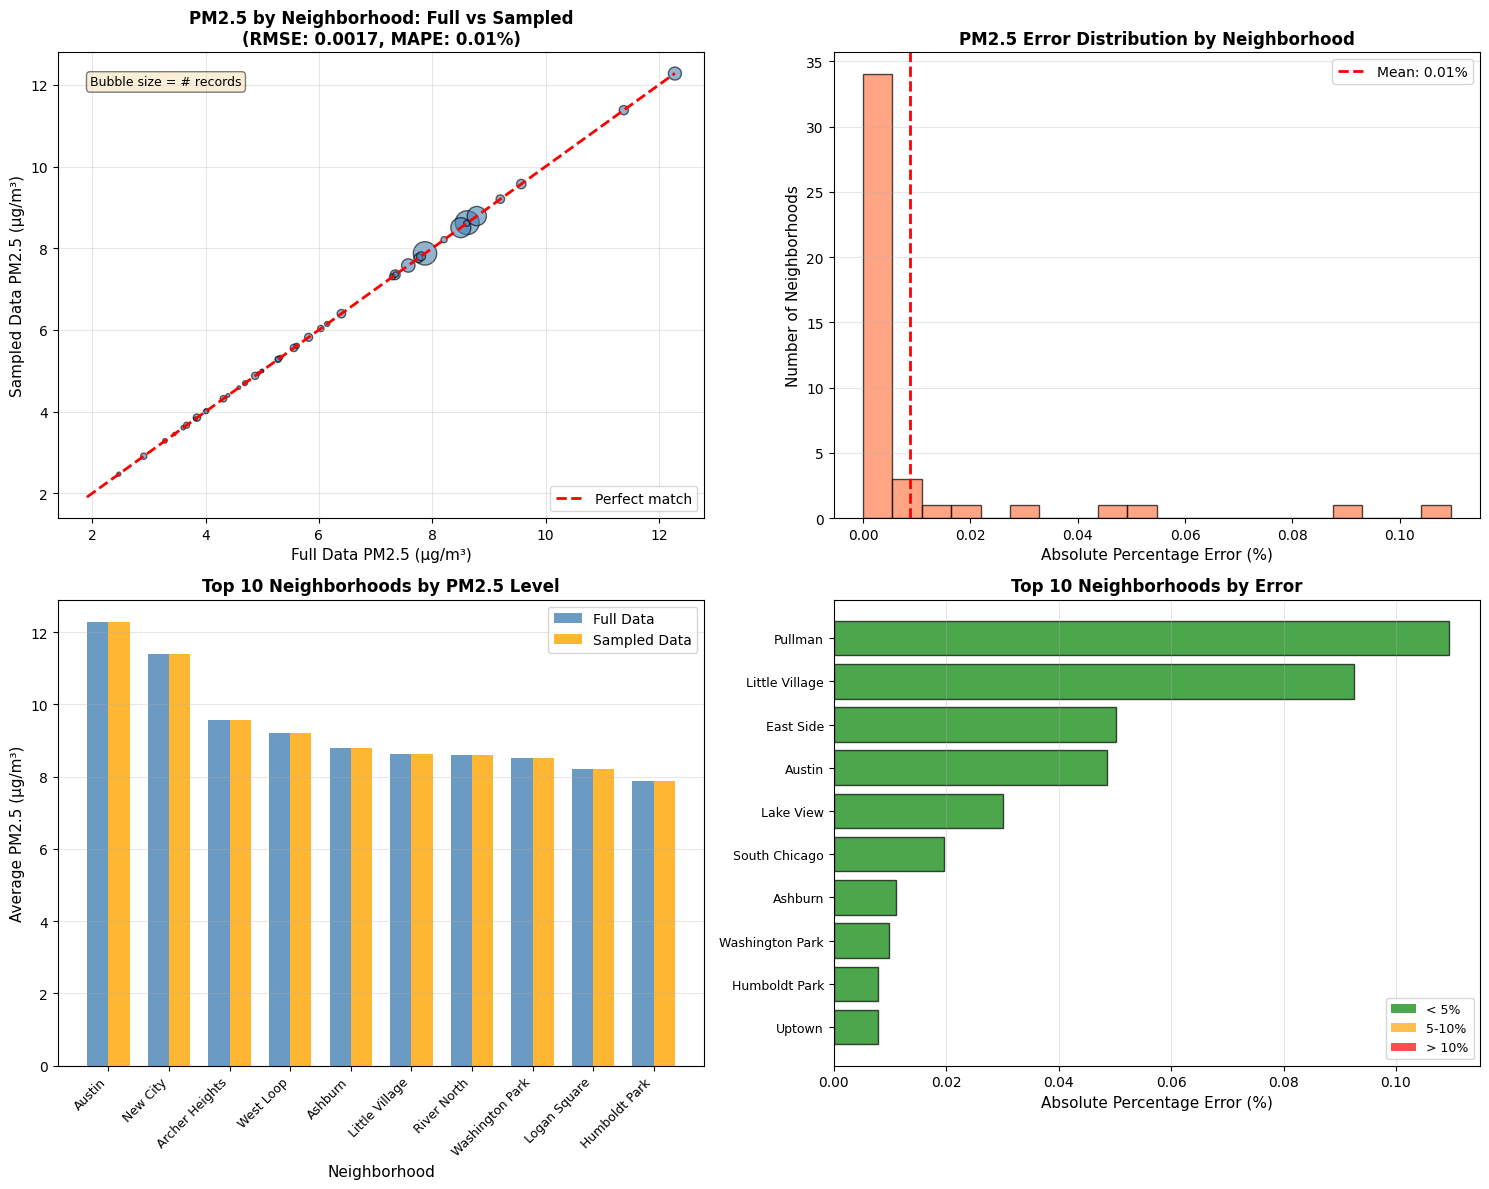


SUMMARY STATISTICS
Total Neighborhoods: 44

PM2.5 Accuracy:
  RMSE: 0.0017 μg/m³
  MAPE: 0.01%

Error Distribution:
  Min Error: 0.00%
  Max Error: 0.11%
  Median Error: 0.00%

Neighborhoods with < 5% error: 44 (100.0%)
Neighborhoods with < 10% error: 44 (100.0%)

Sampling Efficiency: 80% data → 100.0% accuracy


In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert neighborhood errors to pandas for visualization
neighborhood_pd = neighborhood_errors_display.toPandas()

print(f"Visualizing {len(neighborhood_pd)} neighborhoods\n")

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. PM2.5 Scatter: Full vs Sampled by Neighborhood
ax1 = axes[0, 0]
ax1.scatter(neighborhood_pd['avg_PM25_full'], neighborhood_pd['avg_PM25_sampled'], 
           s=neighborhood_pd['total_records']/50, alpha=0.6, c='steelblue', edgecolors='black')
min_val = min(neighborhood_pd['avg_PM25_full'].min(), neighborhood_pd['avg_PM25_sampled'].min())
max_val = max(neighborhood_pd['avg_PM25_full'].max(), neighborhood_pd['avg_PM25_sampled'].max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect match')
ax1.set_xlabel('Full Data PM2.5 (μg/m³)', fontsize=11)
ax1.set_ylabel('Sampled Data PM2.5 (μg/m³)', fontsize=11)
ax1.set_title(f'PM2.5 by Neighborhood: Full vs Sampled\n(RMSE: {metrics["RMSE"]:.4f}, MAPE: {metrics["MAPE"]:.2f}%)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.text(0.05, 0.95, f'Bubble size = # records', transform=ax1.transAxes, 
         fontsize=9, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 2. Error Distribution
ax2 = axes[0, 1]
ax2.hist(neighborhood_pd['absolute_pct_error'], bins=20, edgecolor='black', alpha=0.7, color='coral')
ax2.axvline(metrics['MAPE'], color='red', linestyle='--', linewidth=2, label=f'Mean: {metrics["MAPE"]:.2f}%')
ax2.set_xlabel('Absolute Percentage Error (%)', fontsize=11)
ax2.set_ylabel('Number of Neighborhoods', fontsize=11)
ax2.set_title('PM2.5 Error Distribution by Neighborhood', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

# 3. Top 10 Neighborhoods by PM2.5 Level
ax3 = axes[1, 0]
top_10 = neighborhood_pd.nlargest(10, 'avg_PM25_full')
x = range(len(top_10))
width = 0.35
ax3.bar([i - width/2 for i in x], top_10['avg_PM25_full'], width, label='Full Data', alpha=0.8, color='steelblue')
ax3.bar([i + width/2 for i in x], top_10['avg_PM25_sampled'], width, label='Sampled Data', alpha=0.8, color='orange')
ax3.set_xlabel('Neighborhood', fontsize=11)
ax3.set_ylabel('Average PM2.5 (μg/m³)', fontsize=11)
ax3.set_title('Top 10 Neighborhoods by PM2.5 Level', fontsize=12, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(top_10['neighborhood'], rotation=45, ha='right', fontsize=9)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')

# 4. Top 10 Neighborhoods by Error
ax4 = axes[1, 1]
top_errors = neighborhood_pd.nlargest(10, 'absolute_pct_error')
colors = ['red' if e > 10 else 'orange' if e > 5 else 'green' for e in top_errors['absolute_pct_error']]
ax4.barh(range(len(top_errors)), top_errors['absolute_pct_error'], color=colors, alpha=0.7, edgecolor='black')
ax4.set_yticks(range(len(top_errors)))
ax4.set_yticklabels(top_errors['neighborhood'], fontsize=9)
ax4.set_xlabel('Absolute Percentage Error (%)', fontsize=11)
ax4.set_title('Top 10 Neighborhoods by Error', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')
ax4.invert_yaxis()

# Add error threshold legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', alpha=0.7, label='< 5%'),
                   Patch(facecolor='orange', alpha=0.7, label='5-10%'),
                   Patch(facecolor='red', alpha=0.7, label='> 10%')]
ax4.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*70)
print("SUMMARY STATISTICS")
print("="*70)
print(f"Total Neighborhoods: {len(neighborhood_pd)}")
print(f"\nPM2.5 Accuracy:")
print(f"  RMSE: {metrics['RMSE']:.4f} μg/m³")
print(f"  MAPE: {metrics['MAPE']:.2f}%")
print(f"\nError Distribution:")
print(f"  Min Error: {neighborhood_pd['absolute_pct_error'].min():.2f}%")
print(f"  Max Error: {neighborhood_pd['absolute_pct_error'].max():.2f}%")
print(f"  Median Error: {neighborhood_pd['absolute_pct_error'].median():.2f}%")
print(f"\nNeighborhoods with < 5% error: {(neighborhood_pd['absolute_pct_error'] < 5).sum()} ({(neighborhood_pd['absolute_pct_error'] < 5).sum()/len(neighborhood_pd)*100:.1f}%)")
print(f"Neighborhoods with < 10% error: {(neighborhood_pd['absolute_pct_error'] < 10).sum()} ({(neighborhood_pd['absolute_pct_error'] < 10).sum()/len(neighborhood_pd)*100:.1f}%)")
print(f"\nSampling Efficiency: {SAMPLING_FRACTION*100:.0f}% data → {100-metrics['MAPE']:.1f}% accuracy")
print("="*70)

In [8]:
spark.stop()

26/02/17 22:59:42 WARN StateStore: Error running maintenance thread
java.lang.IllegalStateException: SparkEnv not active, cannot do maintenance on StateStores
	at org.apache.spark.sql.execution.streaming.state.StateStore$.doMaintenance(StateStore.scala:596)
	at org.apache.spark.sql.execution.streaming.state.StateStore$.$anonfun$startMaintenanceIfNeeded$1(StateStore.scala:582)
	at org.apache.spark.sql.execution.streaming.state.StateStore$MaintenanceTask$$anon$1.run(StateStore.scala:442)
	at java.base/java.util.concurrent.Executors$RunnableAdapter.call(Executors.java:539)
	at java.base/java.util.concurrent.FutureTask.runAndReset(FutureTask.java:305)
	at java.base/java.util.concurrent.ScheduledThreadPoolExecutor$ScheduledFutureTask.run(ScheduledThreadPoolExecutor.java:305)
	at java.base/java.util.concurrent.ThreadPoolExecutor.runWorker(ThreadPoolExecutor.java:1136)
	at java.base/java.util.concurrent.ThreadPoolExecutor$Worker.run(ThreadPoolExecutor.java:635)
	at java.base/java.lang.Thread.